In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd

dpi = 150
mpl.rcParams['figure.dpi'] = dpi

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from spatial_decompostion import *

In [23]:
def get_variable_spatial_decompose(mean_swmt, var = "SWMT", reference_period = '1900-2000', 
                                  pert_period = '2090-2100'): 
    ds_decomp = decompose_discrete_full(
    mean_swmt[reference_period][var], mean_swmt[pert_period][var],
    dims=("xh", "yh"))
    return ds_decomp

def get_variable_spatial_sum_reference(mean_swmt, var = "SWMT", reference_period = '1900-2000'): 
    return mean_swmt[reference_period][var].sum(dim=("xh", "yh"))
    
def get_variable_spatial_sum_pert(mean_swmt, var = "SWMT", pert_period = '2090-2100'): 
    return mean_swmt[pert_period][var].sum(dim=("xh", "yh"))
    
def get_variable_integrand_change(mean_swmt, var = "SWMT"): 
    ds_decomp = get_variable_spatial_decompose(mean_swmt, var)
    return ds_decomp["integrand_change"]

def add_bar_numbers(bars, ax, text_height_factor = 2):
    # Grab the color of the bars so we can make the
    # text the same color.
    
    # Add text annotations to the top of the bars.
    # Note, you'll have to adjust this slightly (the 0.3)
    # with different data.
    for bar in bars:
        bar_color = bar.get_facecolor()
        height_diff = np.sign(bar.get_height()) * text_height_factor
        ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() + height_diff,
          round(bar.get_height(), 2),
          horizontalalignment='center',
          color=bar_color,
          weight='bold'
    )

daterange2tuple = lambda x: tuple(map(int, x.split('-')))

In [24]:
SWMT_var_to_label = {
    # heat budget
    "SWMT":             "net surface transformation",

    "SWMT_heat":             "heat",
    "SWMT_heat_latent":      "latent heat",
    "SWMT_heat_frazil":      "frazil",
    "SWMT_heat_longwave":    "longwave",
    "SWMT_heat_shortwave":   "shortwave heat",
    "SWMT_heat_mass_transfer":"mass transfer",
    "SWMT_heat_sensible":    "sensible heat",
    "SWMT_salt_residual":    "salt residual",
    "SWMT_residual":    "residual",

    # salt budget
    "SWMT_salt":             "salt",
    "SWMT_salt_evaporation": "evap",
    "SWMT_salt_precipitation":"precip",
    "SWMT_salt_rivers":      "rivers",
    "SWMT_salt_icebergs":    "icebergs",
    "SWMT_salt_basal_salt":  "basal salt",
    "SWMT_salt_sea_ice":     "sea-ice freeze/melt",
    "SWMT_heat_residual":    "heat residual",
    "SWMT_salt_precip_minus_evaporation": "precip/evap",
    "other_terms": "other terms"

}

### Load in data

In [25]:
expt_colors = dict(); expt_colors["control"] = "#2f74b3"; expt_colors["forced"] = "#cc415a"

In [26]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x

ds = xr.open_dataset(datadir("/model/Southern_Ocean_DSW_1000m_WMT_Budget.zarr"), engine = "zarr")
ds_monthly_SWMT = get_SWMT(ds)

ds = ds.groupby("time.year").mean("time")
ds_SWMT = get_SWMT(ds)
ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]


In [27]:
ds_maximum_sbf_and_psi = xr.open_dataset(datadir("/model/Southern_Ocean_DSW_1000m_max_SWMT.zarr"))

In [28]:
ds_sfc = xr.open_mfdataset(datadir(f"/model/Southern_Ocean_DSW_1100m_WMT_Surface_Fluxes_sigma_slice.nc"), engine = "h5netcdf")
# ds_sfc = ds_sfc.where(ds_sfc.geolat <= 50)
ds_sfc_SWMT = get_SWMT(ds_sfc)
ds_sfc_SWMT["SWMT_residual"] = ds_sfc_SWMT["SWMT_heat_residual"] + ds_sfc_SWMT["SWMT_salt_residual"]

In [29]:
toTg = 1e-9
mass_flux_units_conversion = toTg / (ds_sfc_SWMT.areacello * ds_sfc_SWMT.wet)
mass_flux_units = r"$Tg/s / m^2$"

In [30]:
mean_swmt_ds = xr.open_dataset(datadir("/model/DSW_SWMT_periods.zarr"))
mean_swmt = {
    str(k): mean_swmt_ds.sel(period=k).drop_vars("period")
    for k in mean_swmt_ds.coords["period"].values.tolist()
}

In [31]:
sns.set_theme(context='notebook', style='ticks')

In [32]:
ds_diff_decomp = get_variable_spatial_decompose(mean_swmt, var = "SWMT") 
ds_ref_sum = toTg * get_variable_spatial_sum_reference(mean_swmt, var = "SWMT") 
ds_pert_sum =  toTg * get_variable_spatial_sum_pert(mean_swmt, var = "SWMT") 

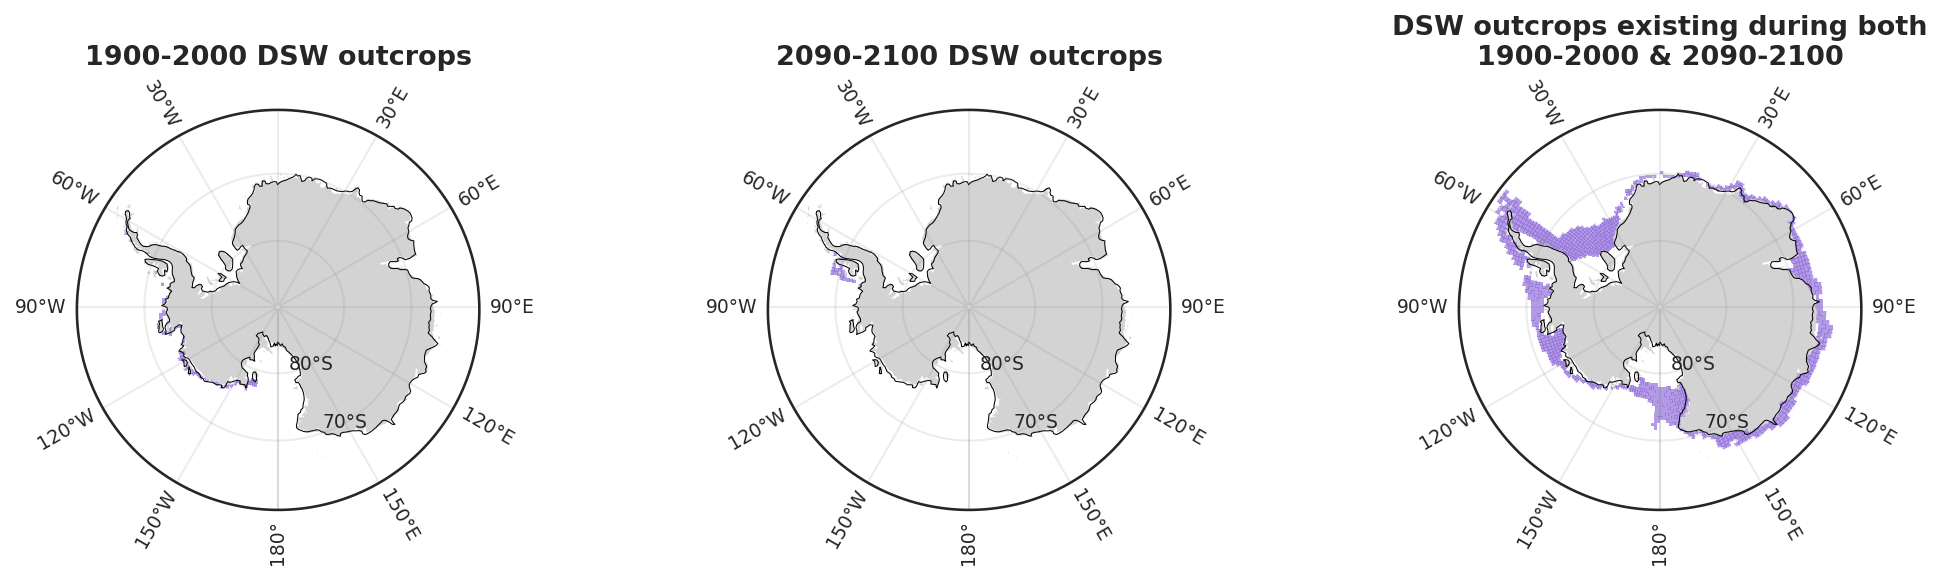

In [33]:
reference_period = '1900-2000'
pert_period = '2090-2100'
times_list = [daterange2tuple(reference_period), daterange2tuple(pert_period)]
nt = len(times_list)

base = ListedColormap(['white','mediumpurple'])
colors = base(np.linspace(0, 1, base.N))
colors[:, -1] = 0.7        # set all alphas to
cmap = ListedColormap(colors)

regions = ["D_f_minus_g", "D_g_minus_f", "D_intersect"]
nr = len(regions)

fig, ax = plt.subplots(1, nr, figsize = (14, 4),
                        subplot_kw={'projection': ccrs.SouthPolarStereo()})
[a.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()) for a in ax.flatten()]

for (i, region) in enumerate(regions):
    cm = plot_antarctic(1.0 * ds_diff_decomp[region], ax[i], 
                        cmap = cmap, norm = None, mask_threshold = -np.inf)
        


ax[0].set_title('-'.join(list(map(str, times_list[0]))) + " DSW outcrops", 
             fontweight = "bold", fontsize = 13, ha='center')

ax[1].set_title('-'.join(list(map(str, times_list[1]))) + " DSW outcrops", 
             fontweight = "bold", fontsize = 13, ha='center')


ax[2].set_title("DSW outcrops existing during both\n" + '-'.join(list(map(str, times_list[0]))) + " & " + '-'.join(list(map(str, times_list[1]))), 
             fontweight = "bold", fontsize = 13, ha='center')

fig.tight_layout()

fig.savefig("plots/S2.DSW_outcrops_Spatial_Differences.png", dpi = 250, bbox_inches = "tight")

In [34]:
ds_sfc_props = xr.open_mfdataset(datadir(f"/model/Southern_Ocean_50S_Monthly_Surface_Fluxes_And_Properties.zarr"))
# Define your custom seasons (example: tropical wet/dry seasons)
def custom_seasons(month):
    """Define custom seasons based on month"""
    if month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:  # all months
        return 'winter'
    else:
        return 'not_winter'

# Apply to your data
season_labels = xr.apply_ufunc(
    custom_seasons, 
    ds_sfc_props.time.dt.month,
    vectorize=True,
    dask='allowed'
)

# Add as coordinate
ds_sfc_props_with_seasons = ds_sfc_props.assign_coords(custom_season=('time', season_labels.data))

ds_sfc_props_winter_data = ds_sfc_props_with_seasons.where(ds_sfc_props_with_seasons.custom_season == 'winter', drop=True)
ds_sfc_props_winter_yearly_averages = ds_sfc_props_winter_data.groupby('time.year').mean('time').compute()

In [35]:
# ds_sfc_sigma_geq = ds_sfc_props_winter_yearly_averages.sel(exp = "forced")
ds_sfc_props_mod = 1 * get_sigma2_at_surface(ds_sfc_props_winter_yearly_averages, keep_vars = False).where(ds_sfc_props_winter_yearly_averages.wet > 0.0)
ds_sfc_props_mod["beta"] = gsw.beta(ds_sfc_props_mod.sa, ds_sfc_props_mod.ct, 0.0)
ds_sfc_props_mod["alpha"] = gsw.alpha(ds_sfc_props_mod.sa, ds_sfc_props_mod.ct, 0.0)

ds_sfc_sigma_geq = 1 * ds_sfc_props_mod
# ds_sfc_sigma_geq_thermo = get_sigma2_at_surface(ds_sfc_sigma_geq, keep_vars = False)

In [36]:
sum_horizontal = lambda ds: ds.sum(["xh", "yh"], skipna = True)
mean_horizontal = lambda ds: ds.mean(["xh", "yh"], skipna = True)

def forcing_at_swmt_maximum(ds, mask):
    nt = len(ds.year)
    exp = ds.exp
    sigma_targets = ds_maximum_sbf_and_psi.max_surface_boundary_flux_density.sel(exp = exp )
    ds_var = ds
    area = ds_var.areacello.where(ds_var.wet > 0.0)

    wet_mask = mask
    weights = (area * wet_mask).where(wet_mask > 0.0)
    
    test_arr = []
    for i in range(nt):
        tmp = ds_var.isel(year = i).sum("sigma2_l")
        # tmp = ds_var.sel(sigma2_l = sigma_targets.values[i]).isel(year = i)
        # tmp = ds_var.sel(sigma2_l = slice(sigma_targets.values[i], None)).isel(year = i).sum("sigma2_l")

        nan_mask = ~np.isnan(tmp)
        weighted_mask = weights * nan_mask
        tmp_weighted = (tmp * weighted_mask)

        avg_var = sum_horizontal(tmp_weighted.where(weighted_mask > 0)) / sum_horizontal(weighted_mask.where(weighted_mask > 0))
        # avg_var = mean_horizontal(tmp.where(weighted_mask > 0)) 
        test_arr += [avg_var.compute()]

    return xr.concat(test_arr, dim = "year").sortby("year").compute()
def area_weighted_average(ds, mask):
    weights = (ds.areacello).where((ds.wet > 0) * (mask > 0) * (~np.isnan(ds))) #maybe don't need * ds.wet
    weighted_ds = (ds * weights).sum(["xh", "yh"], skipna = True) / weights.sum(["xh", "yh"], skipna = True)
    return weighted_ds
def area_weighted_sum(ds, mask):
    weights = (ds.areacello).where((ds.wet > 0) * (mask > 0))
    weighted_ds = (ds * weights).sum(["xh", "yh"], skipna = True)
    return weighted_ds

In [37]:
average_period = lambda ds, period_slice: ds.sel(year = period_slice).mean("year")
get_baselines = lambda ds, var: average_period(ds[var], slice(reference_period[0], reference_period[1]))
get_anomaly = lambda ds, var: average_period(ds[var], slice(pert_period[0], pert_period[1])) - ds[f"{var}_baseline"]
get_anomaly_ts = lambda ds, var: ds[var] - ds[f"{var}_baseline"]


ds_sigma_sfc_decomp = ds_sfc_sigma_geq[["rho2", "ct", "sa"]].sel(exp = "forced")
ds_sigma_sfc_decomp["rho2_baseline"] = get_baselines(ds_sigma_sfc_decomp, "rho2")
ds_sigma_sfc_decomp["ct_baseline"] = get_baselines(ds_sigma_sfc_decomp, "ct")
ds_sigma_sfc_decomp["sa_baseline"] = get_baselines(ds_sigma_sfc_decomp, "sa")


p_ref = 2000 #2000 dbar reference pressure 

# Calculate thermal expansion coefficient alpha (1/K) at reference pressure
ds_sigma_sfc_decomp['alpha_baseline'] = xr.apply_ufunc(
    gsw.alpha, ds_sigma_sfc_decomp["sa_baseline"], ds_sigma_sfc_decomp["ct_baseline"], p_ref, dask="parallelized"
)

# Calculate the haline contraction coefficient beta (kg/g) at reference pressure
ds_sigma_sfc_decomp['beta_baseline'] = xr.apply_ufunc(
    gsw.beta, ds_sigma_sfc_decomp["sa_baseline"], ds_sigma_sfc_decomp["ct_baseline"], p_ref, dask="parallelized"
)


ds_sigma_sfc_decomp["rho2_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "rho2")
ds_sigma_sfc_decomp["ct_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "ct")
ds_sigma_sfc_decomp["sa_anomaly"] = get_anomaly_ts(ds_sigma_sfc_decomp, "sa")

# rho0 = ds_sigma_sfc_decomp["rho2_baseline"] + 1000  #could eb comething else? 
rho0 = 1035
ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"] = -rho0 * ds_sigma_sfc_decomp['alpha_baseline'] * ds_sigma_sfc_decomp["ct_anomaly"]
ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"] =  rho0 * ds_sigma_sfc_decomp['beta_baseline']  * ds_sigma_sfc_decomp["sa_anomaly"]

ds_sigma_sfc_decomp["rho2_anomaly_recon"] = ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"] + ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"]

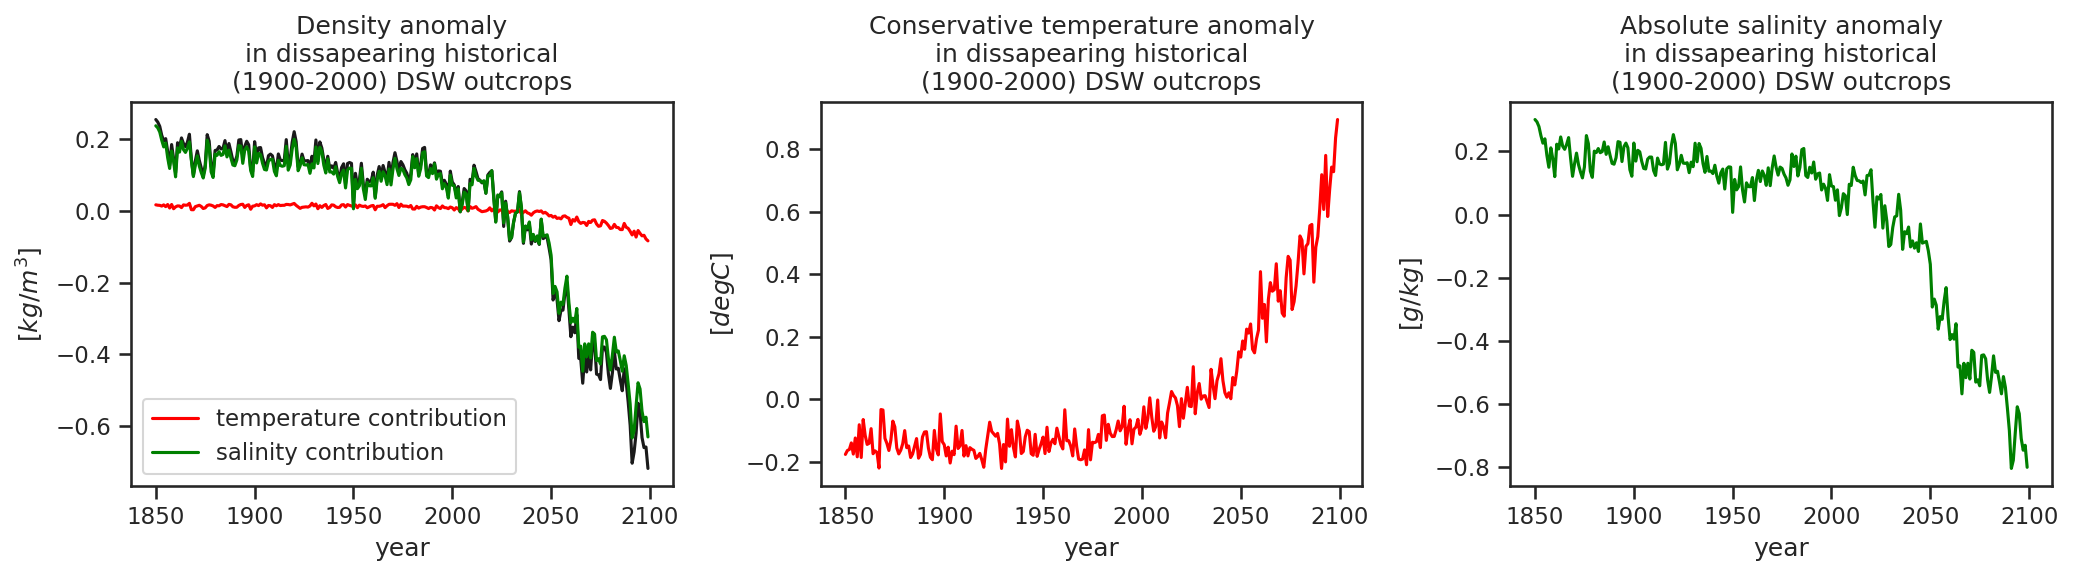

In [38]:
region_of_interest = ds_diff_decomp["D_f"]
# dens_region = density_title.replace('(', '').replace(')', '').replace('\\mathbf', '')

fig, axes = plt.subplots(1, 3, figsize = (14, 4))
temp_color = "red"
sal_color = "green"
ax = axes[0]
area_weighted_average(ds_sigma_sfc_decomp["rho2_anomaly"], region_of_interest).plot(ax=ax, c= "k")

ct_contrib = ds_sigma_sfc_decomp["rho2_anomaly_ct_contrib"]# + ds_sigma_sfc_decomp["rho2_baseline"]
area_weighted_average(ct_contrib, region_of_interest).plot(ax=ax, label= "temperature contribution", c = temp_color)

sa_contrib = ds_sigma_sfc_decomp["rho2_anomaly_sa_contrib"]# + ds_sigma_sfc_decomp["rho2_baseline"]

area_weighted_average(sa_contrib, region_of_interest).plot(ax=ax, label= "salinity contribution", c = sal_color)
ax.legend()
ax.set_title(f"Density anomaly\nin dissapearing historical\n({reference_period}) DSW outcrops")
ax.set_ylabel(r"$[kg/m^3]$")

ax = axes[1]
# plot temperature
temp_line = area_weighted_average(ds_sigma_sfc_decomp["ct_anomaly"], region_of_interest).plot(ax=ax, color=temp_color)
# label and color the left y‑axis for temperature
ax.set_title(f"Conservative temperature anomaly\nin dissapearing historical\n({reference_period}) DSW outcrops")
ax.set_ylabel(r"$[deg C]$")

# twin for salinity
axt = axes[2]
salt_line = area_weighted_average(ds_sigma_sfc_decomp["sa_anomaly"], region_of_interest).plot(ax=axt, color=sal_color)
# label and color the right y‑axis for salinity
axt.set_title(f"Absolute salinity anomaly\nin dissapearing historical\n({reference_period}) DSW outcrops")
axt.set_ylabel(r"$ [g/kg]$")

fig.tight_layout()

fig.savefig("plots/S3.Dissapearing_Outcrop_Thermodynamics.png", dpi = 250, bbox_inches = "tight")

In [39]:
ds_sfc_sigma_geq_thermo_fluxes = 1 * ds_sfc_sigma_geq[["fsitherm", "hfsso", "siconc"]].sel(exp = "forced")

In [40]:
def set_ylabel_with_sci(ax, label):
    """
    Move the scientific notation offset text from the y-axis
    into the ylabel, formatting as 10^n.
    """
    # Force tick/offset calculation
    ax.figure.canvas.draw()

    # Grab the offset string (like '1e8')
    offset = ax.yaxis.get_offset_text().get_text()
    
    # Hide the offset from the axis
    ax.yaxis.offsetText.set_visible(False)

    # Convert '1e8' -> '10^8'
    if offset.startswith("1e"):
        exp = offset.replace("1e", "")
        offset_str = r"$ \times 10^{{{}}}$".format(exp)
    else:
        offset_str = offset  # fallback in case of unusual format
    
    # Update ylabel with scaling
    if offset:
        ax.set_ylabel(f"{label} {offset_str}")
    else:
        ax.set_ylabel(label)

In [43]:
?ax.set_title

Signature: ax.set_title(label, fontdict=None, loc=None, pad=None, *, y=None, **kwargs)
Docstring:
Set a title for the Axes.

Set one of the three available Axes titles. The available titles
are positioned above the Axes in the center, flush with the left
edge, and flush with the right edge.

Parameters
----------
label : str
    Text to use for the title

fontdict : dict

    .. admonition:: Discouraged

       The use of *fontdict* is discouraged. Parameters should be passed as
       individual keyword arguments or using dictionary-unpacking
       ``set_title(..., **fontdict)``.

    A dictionary controlling the appearance of the title text,
    the default *fontdict* is::

       {'fontsize': rcParams['axes.titlesize'],
        'fontweight': rcParams['axes.titleweight'],
        'color': rcParams['axes.titlecolor'],
        'verticalalignment': 'baseline',
        'horizontalalignment': loc}

loc : {'center', 'left', 'right'}, default: :rc:`axes.titlelocation`
    Which title to se

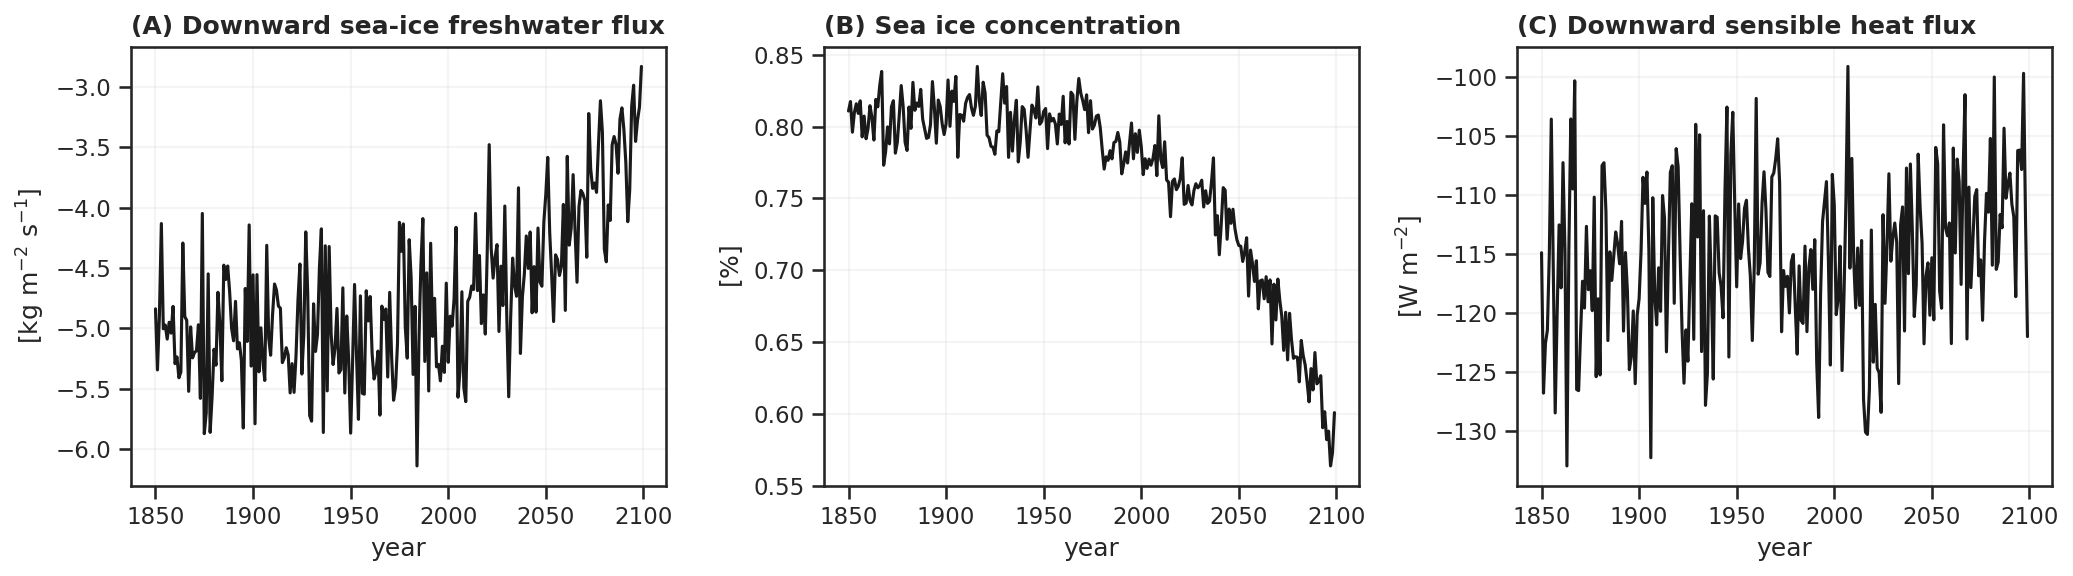

In [53]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4.0))

ax = axes[2]
forcing_at_swmt_maximum(ds_sfc_sigma_geq_thermo_fluxes["hfsso"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title("")
ax.set_title(f"(C) Downward sensible heat flux", fontweight = "bold", loc='left')
set_ylabel_with_sci(ax, r"[W m$^{-2}$]")

ax = axes[1]
area_weighted_average(ds_sfc_sigma_geq_thermo_fluxes["siconc"], ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title("")
ax.set_title(f"(B) Sea ice concentration", fontweight = "bold", loc='left')
set_ylabel_with_sci(ax, r"[$\%$]")

ax = axes[0]
forcing_at_swmt_maximum(ds_sfc_sigma_geq_thermo_fluxes["fsitherm"] * 3.154e+7 / 1000, ds_diff_decomp["D_intersect"]).plot(ax=ax, c= "k")
ax.set_title("")
ax.set_title(f"(A) Downward sea-ice freshwater flux", fontweight = "bold", loc='left')
set_ylabel_with_sci(ax, r"[kg m$^{-2}$ s$^{-1}$]")

# fig.suptitle(f"Yearly-averaged quantities in DSW outcrops", fontweight = "bold")
fig.tight_layout()
[a.grid(alpha = 0.2) for a in axes]
fig.savefig("plots/5.Remaining_DSW_Outcrop_Fluxes.png", dpi = 150, bbox_inches = "tight")
#potential explanation for downward sensible heat fluxes: cabbeling. alpha must be negative zero in order for cooling to cause a decrease in density 